# NB04: Interpretation and discovery

SHAP-based interpretation of M2 (CLR + genus-weighted + env):

**H4**: Metal-gene functional categories (genus-weighted features) rank above taxonomy (CLR) in
SHAP importance for ≥2 of 4 target metals.
- Success: sum of GW SHAP > sum of CLR SHAP for ≥2 metals.

**Discovery analyses**:
1. Top-20 CLR genera by mean |SHAP| per metal (which microbial taxa drive prediction?)
2. Top-5 genus-weighted genera per functional category per metal
3. SHAP summary beeswarm (M2, top 20 features)
4. Threshold metrics at regulatory cutoffs (Cu>100, Zn>300, Pb>100, Ni>50 ppm)

**Outputs**
- `data/shap_importance.csv`
- `data/shap_by_category.csv`
- `data/threshold_metrics.csv`
- `figures/shap_category_bar_{target}.png`
- `figures/shap_top_genera_{target}.png`

In [1]:
import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

for _cand in [Path.cwd() / 'scripts', Path.cwd().parent / 'scripts']:
    if _cand.exists():
        sys.path.insert(0, str(_cand))
        break

DATA_DIR = next(p for p in [Path.cwd() / 'data', Path.cwd().parent / 'data'] if p.exists())
FIG_DIR  = next(p for p in [Path.cwd() / 'figures', Path.cwd().parent / 'figures'] if p.exists())

from modelling import TARGETS, get_features, fit_final_model, _drop_nan_rows
from evaluation import (
    compute_shap_importance,
    aggregate_shap_by_category,
    top_clr_genera,
    threshold_metrics,
    plot_shap_category_bar,
)

feature_matrix = pd.read_parquet(DATA_DIR / 'feature_matrix.parquet')
print(f'Feature matrix: {feature_matrix.shape}')

Feature matrix: (42037, 354)


## 1. SHAP for M2 (fit on full training set)

Fit M2 on all training data, compute TreeExplainer SHAP values.

In [2]:
import shap

all_shap = []

for target in TARGETS:
    if target not in feature_matrix.columns:
        continue
    print(f'Computing SHAP for M2 × {target}...')
    m = fit_final_model(feature_matrix, target, 'M2', model_type='xgboost')
    X = get_features(feature_matrix, 'M2')
    Xc, _ = _drop_nan_rows(X, feature_matrix[target])
    shap_df = compute_shap_importance(m, Xc, target)
    all_shap.append(shap_df)

shap_importance = pd.concat(all_shap, ignore_index=True)
shap_importance.to_csv(DATA_DIR / 'shap_importance.csv', index=False)
print(f'Saved shap_importance.csv ({len(shap_importance)} rows)')

Computing SHAP for M2 × log_Cu_ppm...


Computing SHAP for M2 × log_Zn_ppm...


Computing SHAP for M2 × log_Pb_ppm...


Computing SHAP for M2 × log_Ni_ppm...


Saved shap_importance.csv (1292 rows)


## 2. SHAP aggregated by feature category

In [3]:
shap_cat = aggregate_shap_by_category(shap_importance)
shap_cat.to_csv(DATA_DIR / 'shap_by_category.csv', index=False)

print('SHAP by category:')
print(shap_cat.pivot_table(index='category', columns='target', values='mean_abs_shap').round(4))

SHAP by category:
target                   log_Cu_ppm  log_Ni_ppm  log_Pb_ppm  log_Zn_ppm
category                                                               
CLR (taxonomy)               0.1289      0.2590      0.1101      0.0857
Env_mobility                 0.6347      0.7808      0.4120      0.4293
Env_soil/climate             0.5392      1.1124      0.6301      0.3647
GW_PCA                       0.0039      0.0119      0.0058      0.0040
GW_defense_clusters          0.0033      0.0088      0.0025      0.0024
GW_homeostasis_clusters      0.0033      0.0043      0.0045      0.0031
GW_metabolism_clusters       0.0000      0.0000      0.0000      0.0000
GW_metal_clusters            0.0080      0.0181      0.0124      0.0151
GW_metal_core_fraction       0.0020      0.0024      0.0016      0.0016


## 3. H4: GW feature categories vs CLR taxonomy in SHAP

**Success**: sum of GW SHAP > sum of CLR SHAP for ≥2 of 4 metals.

In [4]:
h4_records = []
for target in TARGETS:
    sub = shap_cat[shap_cat['target'] == target]
    clr_shap = sub[sub['category'] == 'CLR (taxonomy)']['mean_abs_shap'].sum()
    gw_shap  = sub[sub['category'].str.startswith('GW')]['mean_abs_shap'].sum()
    env_shap = sub[sub['category'].str.startswith('Env')]['mean_abs_shap'].sum()
    h4_records.append({
        'target': target,
        'CLR_shap': clr_shap,
        'GW_shap': gw_shap,
        'Env_shap': env_shap,
        'GW_beats_CLR': gw_shap > clr_shap,
    })

h4_df = pd.DataFrame(h4_records)
print('H4: GW vs CLR SHAP comparison:')
print(h4_df.to_string(index=False))
n_h4 = h4_df['GW_beats_CLR'].sum()
print(f'\nH4 OUTCOME: {"SUPPORTED" if n_h4 >= 2 else "NOT SUPPORTED"} ({n_h4}/4 metals GW > CLR)')

H4: GW vs CLR SHAP comparison:
    target  CLR_shap  GW_shap  Env_shap  GW_beats_CLR
log_Cu_ppm  0.128930 0.020437  1.173946         False
log_Zn_ppm  0.085674 0.026269  0.794062         False
log_Pb_ppm  0.110116 0.026851  1.042076         False
log_Ni_ppm  0.258988 0.045440  1.893222         False

H4 OUTCOME: NOT SUPPORTED (0/4 metals GW > CLR)


## 4. Top CLR genera per target


Top 10 CLR genera for log_Cu_ppm:
          genus  mean_abs_shap
   nitrosospira       0.015303
   methanothrix       0.005676
 steroidobacter       0.004123
 actinocorallia       0.003625
     nitrospira       0.003529
     pedobacter       0.002945
aciditerrimonas       0.002812
    asprobacter       0.002395
   microlunatus       0.002326
 nitrososphaera       0.002321


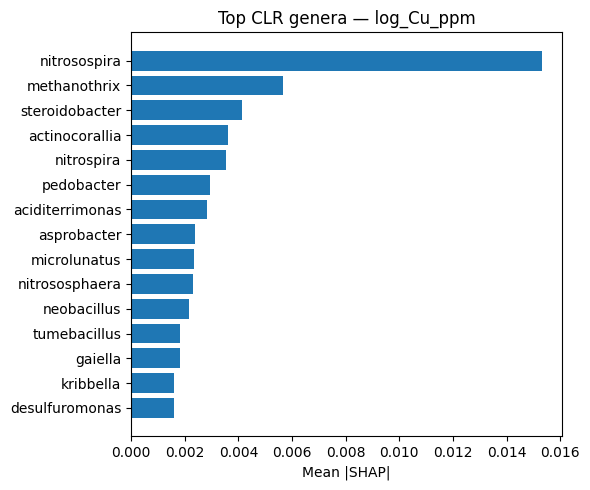


Top 10 CLR genera for log_Zn_ppm:
           genus  mean_abs_shap
  nitrososphaera       0.014524
     neobacillus       0.002709
         gaiella       0.002344
    sulfuricella       0.002036
      morganella       0.001930
    pseudolabrys       0.001679
  nitrosopumilus       0.001580
    povalibacter       0.001541
     aquisphaera       0.001456
anaeromyxobacter       0.001378


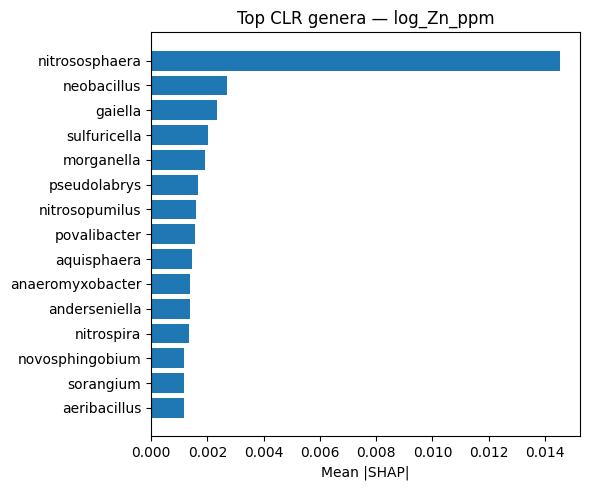


Top 10 CLR genera for log_Pb_ppm:
           genus  mean_abs_shap
   acinetobacter       0.005059
   agrobacterium       0.004235
actinomarinicola       0.004099
     neobacillus       0.003851
  nitrososphaera       0.003061
     ramlibacter       0.002568
  terrimicrobium       0.002420
    methanothrix       0.002022
  bradyrhizobium       0.001778
   simplicispira       0.001744


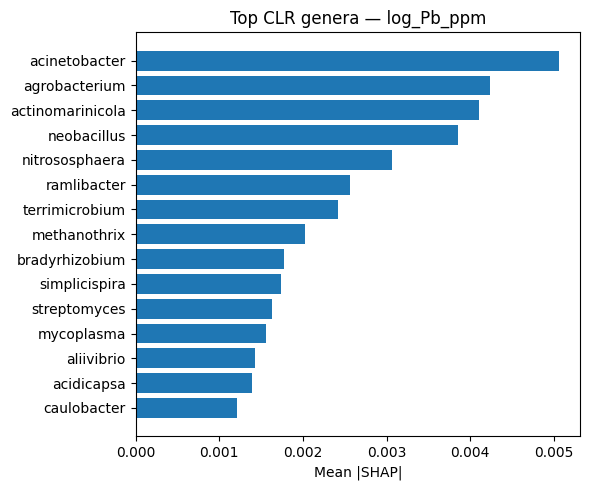


Top 10 CLR genera for log_Ni_ppm:
                genus  mean_abs_shap
              lentzea       0.026379
          xenorhabdus       0.018352
       rhodomicrobium       0.017200
         methanothrix       0.016583
candidatus koribacter       0.008292
       bradyrhizobium       0.005076
           pedobacter       0.004917
        catenulispora       0.003806
       planomicrobium       0.003671
     sphingobacterium       0.003291


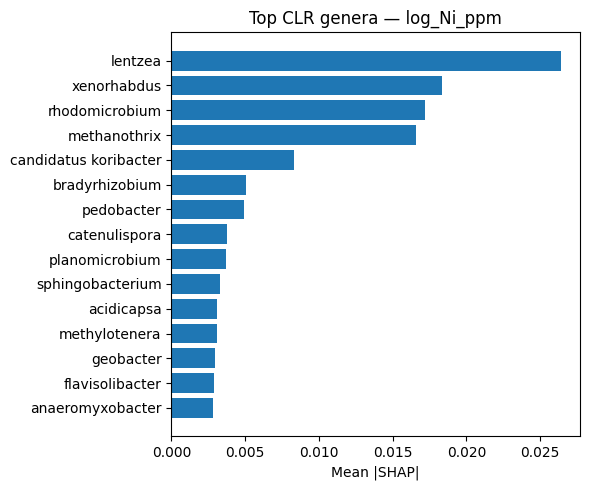

In [5]:
for target in TARGETS:
    if shap_importance[shap_importance['target'] == target].empty:
        continue
    top_genera = top_clr_genera(shap_importance, target, top_n=20)
    print(f'\nTop 10 CLR genera for {target}:')
    print(top_genera.head(10).to_string(index=False))

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.barh(top_genera['genus'][:15][::-1], top_genera['mean_abs_shap'][:15][::-1])
    ax.set_xlabel('Mean |SHAP|')
    ax.set_title(f'Top CLR genera — {target}')
    plt.tight_layout()
    plt.savefig(FIG_DIR / f'shap_top_genera_{target}.png', dpi=150, bbox_inches='tight')
    plt.show()

## 5. SHAP category bar plots

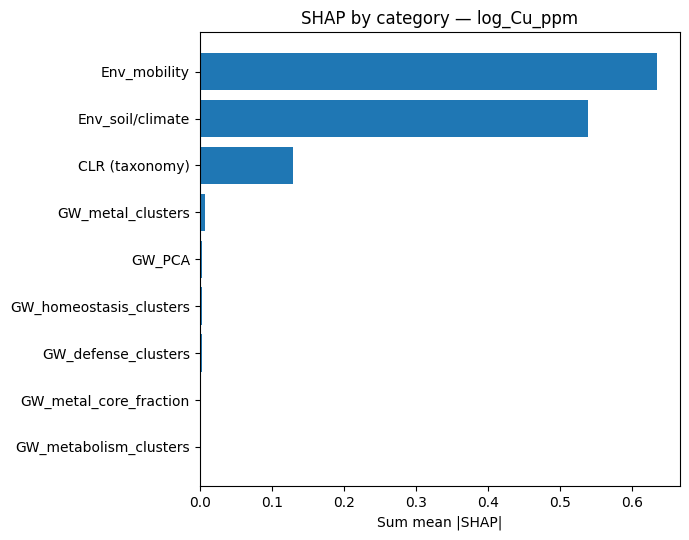

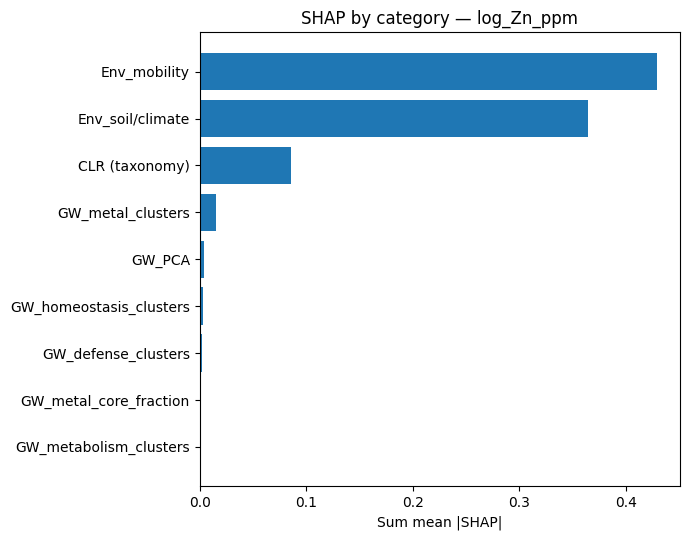

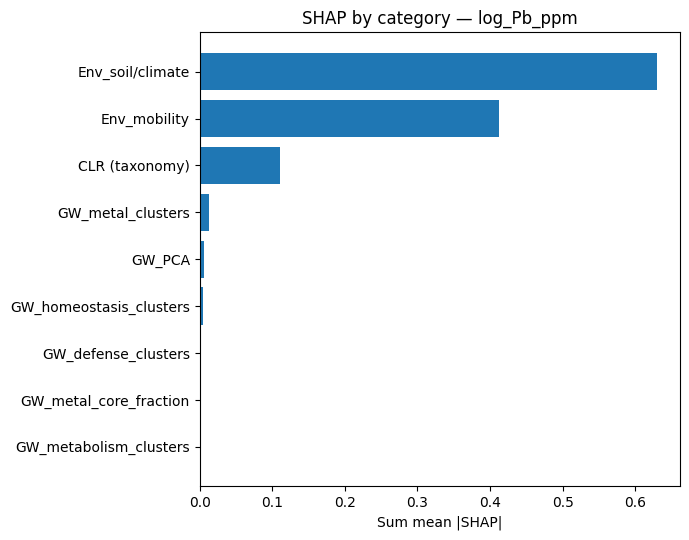

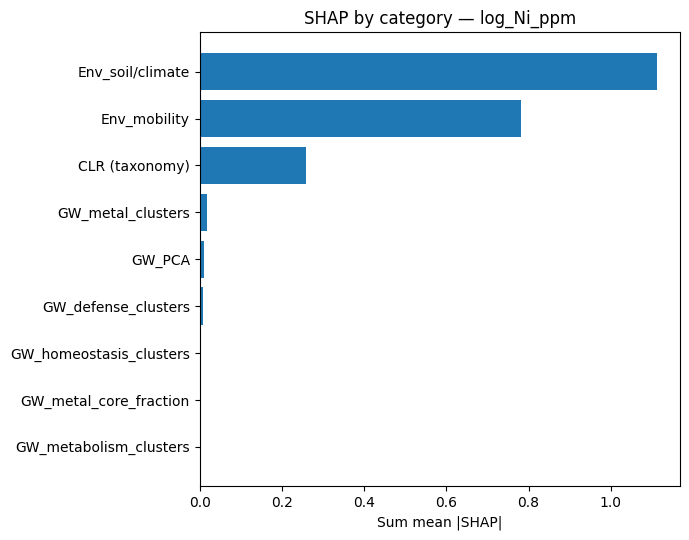

In [6]:
for target in TARGETS:
    if shap_importance[shap_importance['target'] == target].empty:
        continue
    plot_shap_category_bar(
        shap_cat, target,
        out_path=FIG_DIR / f'shap_category_bar_{target}.png',
    )

## 6. Threshold metrics at regulatory cutoffs

In [7]:
thresh_records = []
oof_preds = pd.read_parquet(DATA_DIR / 'oof_predictions.parquet')

for target in TARGETS:
    if target not in feature_matrix.columns:
        continue
    oof_col = f'M2_{target}'
    if oof_col not in oof_preds.columns:
        print(f'No OOF column {oof_col} — skipping')
        continue

    y_true = feature_matrix[target]
    y_pred = oof_preds[oof_col].reindex(feature_matrix.index)
    valid  = y_true.notna() & y_pred.notna()
    y_true_v = y_true[valid]
    y_pred_v  = y_pred[valid]

    metrics = threshold_metrics(y_true_v.values, y_pred_v.values, target)
    metrics['target'] = target
    metrics['n'] = int(valid.sum())
    thresh_records.append(metrics)

thresh_df = pd.DataFrame(thresh_records)
thresh_df.to_csv(DATA_DIR / 'threshold_metrics.csv', index=False)
print('Threshold metrics (M2, OOF predictions):')
print(thresh_df[['target', 'sensitivity', 'specificity', 'threshold', 'n']].round(3).to_string(index=False))

Threshold metrics (M2, OOF predictions):
    target  sensitivity  specificity  threshold     n
log_Cu_ppm        0.015        0.979      4.615 24378
log_Zn_ppm        0.000        1.000      5.707 27055
log_Pb_ppm        0.000        1.000      4.615 26238
log_Ni_ppm        0.462        0.307      3.932 28576
